# Classification using Decision Trees - Exercise

In this exercise, we want to predict if a certain passanger from the Titanic survived or not (binary classification) using a Decision Tree classifier.

**1. Import pandas and the dataset ``titanic.csv``**

| Variable | Definition                                 | Key                                            |
|----------|--------------------------------------------|------------------------------------------------|
| survival | Survival                                   | 0 = No, 1 = Yes                                |
| pclass   | Ticket class                               | 1 = 1st, 2 = 2nd, 3 = 3rd                      |
| sex      | Sex                                        |                                                |
| Age      | Age in years                               |                                                |
| sibsp    | # of siblings / spouses aboard the Titanic |                                                |
| parch    | # of parents / children aboard the Titanic |                                                |
| ticket   | Ticket number                              |                                                |
| fare     | Passenger fare                             |                                                |
| cabin    | Cabin number                               |                                                |
| embarked | Port of Embarkation                        | C = Cherbourg, Q = Queenstown, S = Southampton |

In [10]:
import pandas as pd

dataset = pd.read_csv("titanic.csv")
dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**2. Drop the features / columns that you think that doesn't add any additional information for our ML algo**

In [11]:
dataset = dataset.drop(labels=['PassengerId', 'Name', 'Ticket', 'Fare', 'Cabin', 'Embarked'], axis='columns')


**3. Check if there are any missing values**

HINT: Use the ``isnull()`` and ``sum()`` methods.

In [12]:
#dataset.shape
dataset.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
dtype: int64

**4. Drop the lines containing any missing values**

HINT: To drop, use the ``dropna()``.

In [13]:
dataset = dataset.dropna()
#dataset.shape
dataset.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
dtype: int64

**5. Select X and Y sets**

In [14]:
y = dataset.iloc[ : , :1]
X = dataset.iloc[ : , 1: ]

**6. Convert ``male`` and ``female`` data to ``0`` and ``1`` (enconding)**

In [17]:
X = X.replace(to_replace=['male', 'female'], value=[0, 1])
X

,Pclass,Sex,Age,SibSp,Parch
0,3,0,22.0,1,0
1,1,1,38.0,1,0
2,3,1,26.0,0,0
3,1,1,35.0,1,0
4,3,0,35.0,0,0
...,...,...,...,...,...
885,3,1,39.0,0,5
886,2,0,27.0,0,0
887,1,1,19.0,0,0
889,1,0,26.0,0,0


**7. Split the dataset into train and test subsets: 80% for training and 20% for testing**

HINT: Use the ``train_test_split`` method from the ``sklearn.model_selection`` package.

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y, random_state=1)

**8. Train a Decision Tree Classifier**

In [19]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(random_state=5)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=5)

**9. Make the necessary prediction**

In [20]:
y_pred = classifier.predict(X_test)

**10. Create a confusion matrix**

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=[0,1])
confusion = pd.DataFrame(cm, index=['not survive', 'survive'],
                         columns=['predicted not survive','predicted survive'])
confusion

,predicted not survive,predicted survive
not survive,70,15
survive,18,40


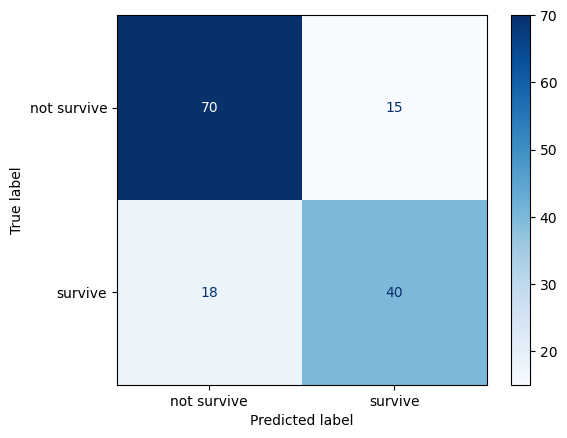

In [29]:
import matplotlib as plt

cm_fig = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['not survive', 'survive'])
cm_fig.plot(cmap='Blues')

**11. Print a classification report**

In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.82      0.81        85
           1       0.73      0.69      0.71        58

    accuracy                           0.77       143
   macro avg       0.76      0.76      0.76       143
weighted avg       0.77      0.77      0.77       143



**12. Can we improve? How?**

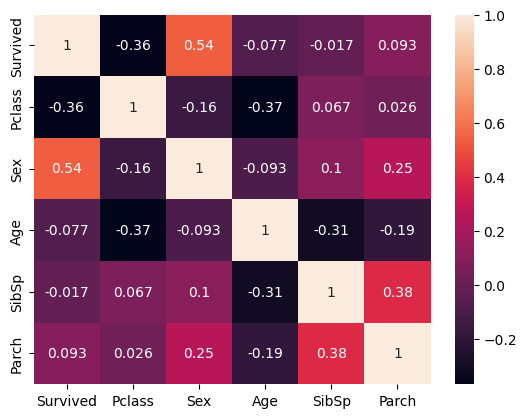

In [34]:
%pip install seaborn
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt

dataset = dataset.replace(to_replace=['male', 'female'], value=[0, 1])

sns.heatmap(dataset.corr(), annot=True)
plt.show()

In [35]:
dataset = pd.read_csv("titanic.csv")
dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [36]:
dataset = dataset.drop(labels=['PassengerId', 'Name', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Parch', 'SibSp', 'Age'], axis='columns')


In [37]:
dataset.isnull().sum()

Survived    0
Pclass      0
Sex         0
dtype: int64

In [44]:
y = dataset.iloc[ : , :1]
X = dataset.iloc[ : , 1: ]

In [46]:
X = X.replace(to_replace=['male', 'female'], value=[0, 1])

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y, random_state=1)

In [50]:
classifier = DecisionTreeClassifier(random_state=5)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=5)

In [51]:
y_pred = classifier.predict(X_test)

In [52]:
cm = confusion_matrix(y_test, y_pred, labels=[0,1])
confusion = pd.DataFrame(cm, index=['not survive', 'survive'],
                         columns=['predicted not survive','predicted survive'])
confusion

,predicted not survive,predicted survive
not survive,108,2
survive,33,36


In [53]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.98      0.86       110
           1       0.95      0.52      0.67        69

    accuracy                           0.80       179
   macro avg       0.86      0.75      0.77       179
weighted avg       0.84      0.80      0.79       179



In [ ]:
just a little bit better...